# S2DIP — Visualize bCARS Denoising Results

Loads the S2DIP result (`results/bcars/bcars_denoised_final.mat`) and visualizes the clean,
noisy, and denoised cubes **rescaled back to the original physical bCARS signal** using the
stored `norm_min` / `norm_max`. PSNR is reported in the normalized [0,1] space the method
optimizes in (affine-invariant, so the dB values are identical to physical-space PSNR with a
matching data range).

In [30]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import os, glob

# ── paths ───────────────────────────────────────────────────────────
# RESULT_PATH = 'results/bcars/bcars_denoised_final.mat'
RESULT_PATH = 'results/bcars/dip_gridsearch_spectraltv_fine_10000/spec_tv0.001_spec_order2_lr0.005/dip_best.mat'
RESULTS_DIR = 'results/bcars/dip_gridsearch_spectraltv_fine_10000/spec_tv0.001_spec_order2_lr0.005/'   # for the checkpoint-progression cell

# display bands spread across the 695-band cube (for false-colour RGB)
RGB_BANDS = (100, 350, 600)
# ─────────────────────────────────────────────────────────────────

## 1  Load results & rescale to the original physical signal

In [31]:
res = sio.loadmat(RESULT_PATH)

norm_min = float(res['norm_min'].flat[0])
norm_max = float(res['norm_max'].flat[0])

def to_phys(cube):
    """Map a normalized [0,1] cube back to the original physical bCARS signal."""
    return cube * (norm_max - norm_min) + norm_min

# normalized cubes (what the network sees / what PSNR uses)
clean_n    = np.clip(np.float32(res['img_clean']), 0, 1)   # (320, 320, 695)
noisy_n    = np.float32(res['y_0_real'])
denoised_n = np.float32(res['denoised'])

# physical-scale cubes (original signal). `denoised_phys` is stored directly.
clean    = to_phys(clean_n)
noisy    = to_phys(noisy_n)
denoised = np.float32(res['denoised_phys'])

psnr_history = np.float32(res['psnr_history'])   # rows of (iter, psnr_gt)

print(f'Cube shape      : {clean.shape}')
print(f'Normalisation   : min={norm_min:.5f}  max={norm_max:.5f}')
print(f'clean  (phys)   : [{clean.min():.4f}, {clean.max():.4f}]')
print(f'noisy  (phys)   : [{noisy.min():.4f}, {noisy.max():.4f}]')
print(f'denoised (phys) : [{denoised.min():.4f}, {denoised.max():.4f}]')
if psnr_history.size:
    best_i = int(np.argmax(psnr_history[:, 1]))
    print(f'\nPSNR_gt final   : {psnr_history[-1, 1]:.2f} dB  (iter {int(psnr_history[-1, 0])})')
    print(f'PSNR_gt best    : {psnr_history[best_i, 1]:.2f} dB  (iter {int(psnr_history[best_i, 0])})')

Cube shape      : (320, 320, 695)
Normalisation   : min=-0.09728  max=0.11112
clean  (phys)   : [-0.0685, 0.0773]
noisy  (phys)   : [-0.0973, 0.1111]
denoised (phys) : [-0.0713, 0.0730]

PSNR_gt final   : 45.29 dB  (iter 9999)
PSNR_gt best    : 45.99 dB  (iter 9150)


## 2  PSNR vs iteration  (convergence / early-stopping)

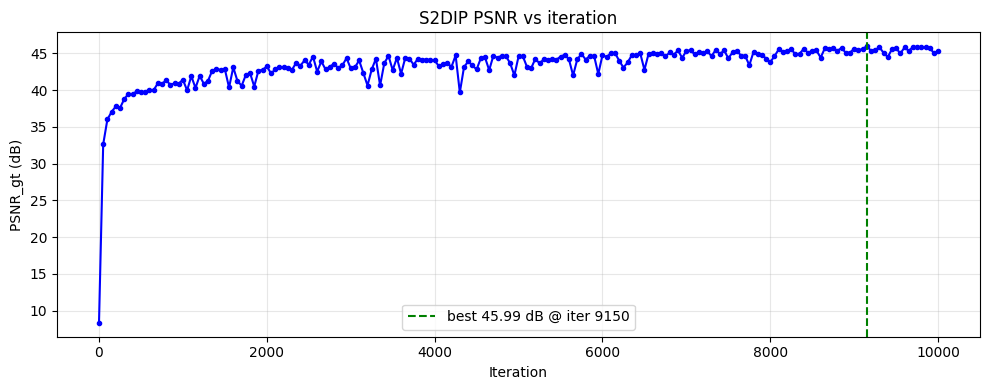

In [32]:
if psnr_history.size:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(psnr_history[:, 0], psnr_history[:, 1], 'b-o', ms=3)
    best_i = int(np.argmax(psnr_history[:, 1]))
    ax.axvline(psnr_history[best_i, 0], color='g', ls='--',
               label=f'best {psnr_history[best_i, 1]:.2f} dB @ iter {int(psnr_history[best_i, 0])}')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('PSNR_gt (dB)')
    ax.set_title('S2DIP PSNR vs iteration')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print('No psnr_history stored.')

## 3  False-colour RGB overview

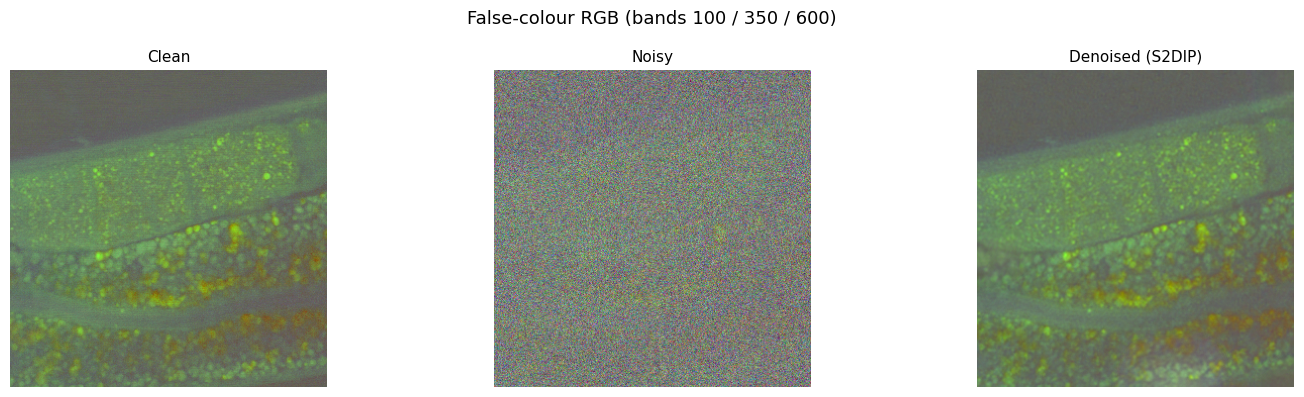

In [33]:
def to_rgb(cube, bands=RGB_BANDS):
    """Pick three bands and stretch to [0,1] for display."""
    r, g, b = bands
    rgb = np.stack([cube[:, :, r], cube[:, :, g], cube[:, :, b]], axis=-1)
    lo, hi = rgb.min(), rgb.max()
    return np.clip((rgb - lo) / (hi - lo + 1e-8), 0, 1)

titles = ['Clean', 'Noisy', 'Denoised (S2DIP)']
cubes  = [clean, noisy, denoised]

fig, axes = plt.subplots(1, len(titles), figsize=(5 * len(titles), 4))
for ax, title, cube in zip(axes, titles, cubes):
    ax.imshow(to_rgb(cube))
    ax.set_title(title, fontsize=11)
    ax.axis('off')
plt.suptitle(f'False-colour RGB (bands {RGB_BANDS[0]} / {RGB_BANDS[1]} / {RGB_BANDS[2]})', fontsize=13)
plt.tight_layout(); plt.show()

## 4  Single-band comparison  (physical signal)

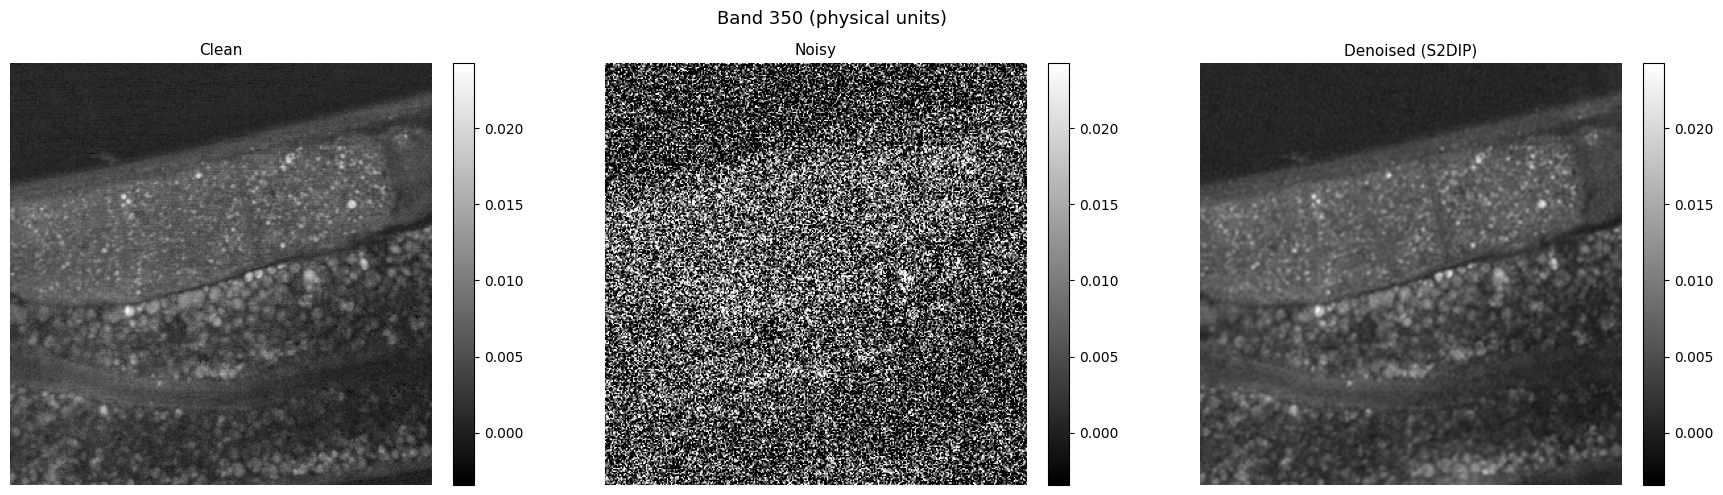

In [34]:
BAND = 350  # ← change to any band 0–694

titles = ['Clean', 'Noisy', 'Denoised (S2DIP)']
cubes  = [clean, noisy, denoised]
vmin, vmax = clean[:, :, BAND].min(), clean[:, :, BAND].max()

fig, axes = plt.subplots(1, len(titles), figsize=(6 * len(titles), 5))
for ax, title, cube in zip(axes, titles, cubes):
    im = ax.imshow(cube[:, :, BAND], cmap='gray', vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=11)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.suptitle(f'Band {BAND} (physical units)', fontsize=13)
plt.tight_layout(); plt.show()

## 5  Residual maps  (|denoised − clean|, physical)

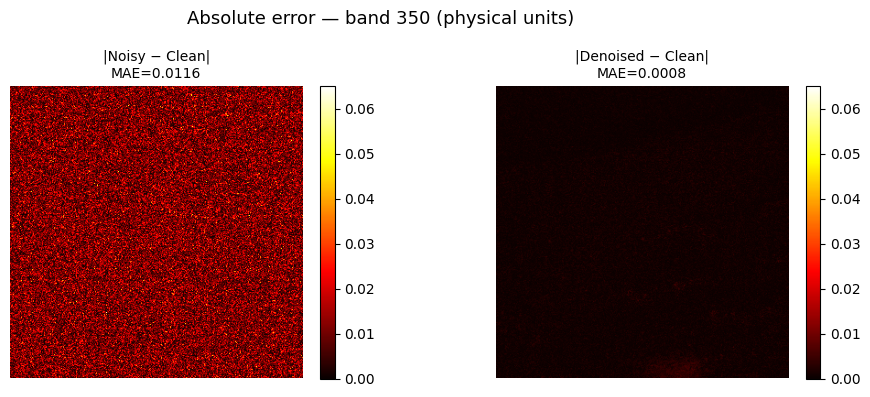

In [35]:
BAND = 350

res_noisy    = np.abs(noisy[:, :, BAND]    - clean[:, :, BAND])
res_denoised = np.abs(denoised[:, :, BAND] - clean[:, :, BAND])
vmax_r = max(res_noisy.max(), res_denoised.max())

residuals = [
    ('|Noisy − Clean|',          res_noisy),
    ('|Denoised − Clean|',       res_denoised),
]

fig, axes = plt.subplots(1, len(residuals), figsize=(5 * len(residuals), 4))
for ax, (title, r) in zip(axes, residuals):
    im = ax.imshow(r, cmap='hot', vmin=0, vmax=vmax_r)
    ax.set_title(f'{title}\nMAE={r.mean():.4f}', fontsize=10)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.suptitle(f'Absolute error — band {BAND} (physical units)', fontsize=13)
plt.tight_layout(); plt.show()

## 6  Per-band PSNR  (normalized [0,1] space)

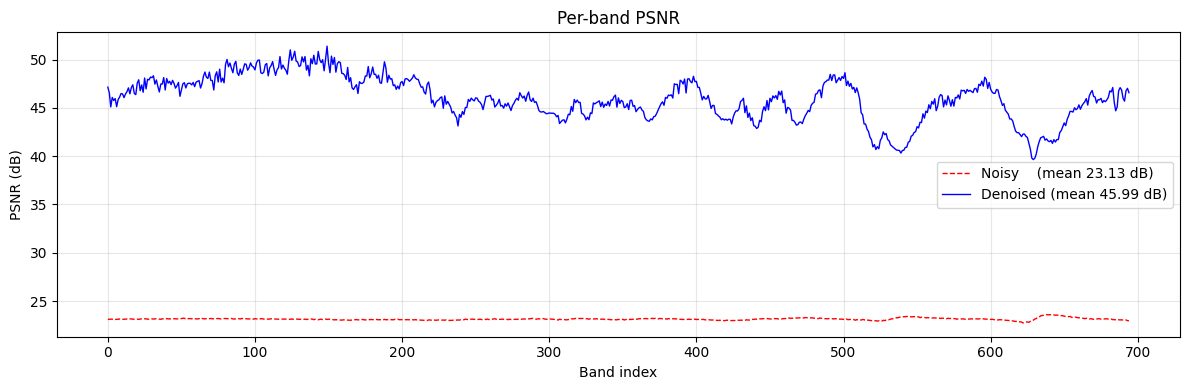

In [36]:
import math

def psnr_band(a, b):
    """PSNR over [0,1]-normalized bands (data_range=1)."""
    a = np.clip(a, 0, 1); b = np.clip(b, 0, 1)
    mse = np.mean((a - b) ** 2)
    return 10 * math.log10(1.0 / mse) if mse > 0 else float('inf')

bands = np.arange(clean_n.shape[2])
psnr_noisy    = [psnr_band(noisy_n[:, :, b],    clean_n[:, :, b]) for b in bands]
psnr_denoised = [psnr_band(denoised_n[:, :, b], clean_n[:, :, b]) for b in bands]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(bands, psnr_noisy,    'r--', lw=1, label=f'Noisy    (mean {np.mean(psnr_noisy):.2f} dB)')
ax.plot(bands, psnr_denoised, 'b-',  lw=1, label=f'Denoised (mean {np.mean(psnr_denoised):.2f} dB)')
ax.set_xlabel('Band index'); ax.set_ylabel('PSNR (dB)')
ax.set_title('Per-band PSNR'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 7  Spectral signature at a pixel  (physical signal)

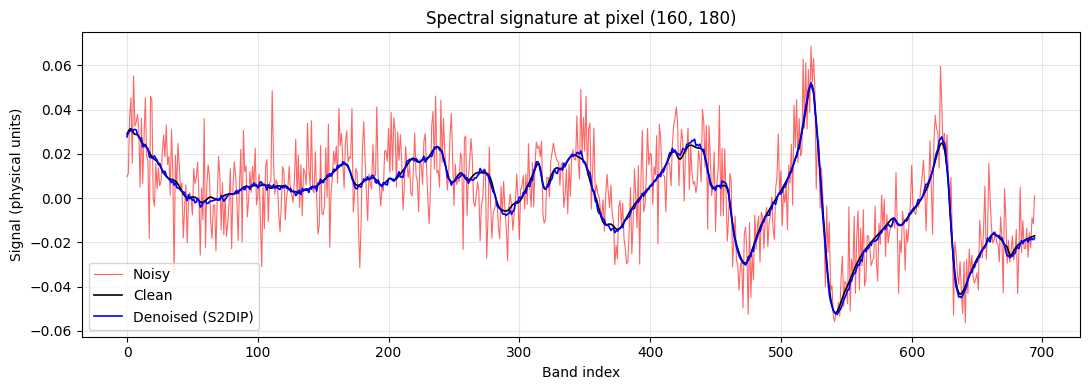

In [37]:
ROW, COL = 160, 180   # ← pick any pixel

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(noisy[ROW, COL, :],    'r-',  lw=0.8, alpha=0.6, label='Noisy')
ax.plot(clean[ROW, COL, :],    'k-',  lw=1.2,            label='Clean')
ax.plot(denoised[ROW, COL, :], 'b-',  lw=1.2,            label='Denoised (S2DIP)')
ax.set_xlabel('Band index'); ax.set_ylabel('Signal (physical units)')
ax.set_title(f'Spectral signature at pixel ({ROW}, {COL})')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 8  Checkpoint progression  (optional)

Shows how a single band evolves across the saved `bcars_denoised_iter*.mat` checkpoints.

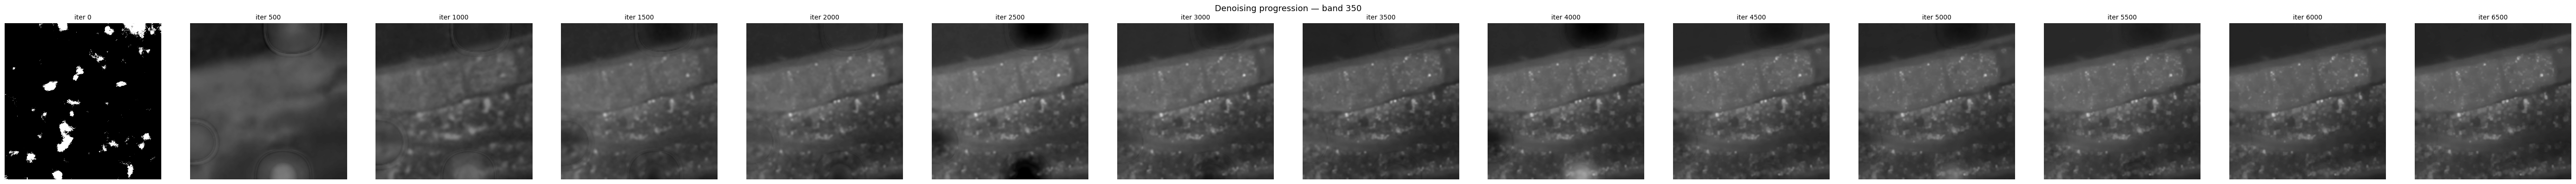

In [18]:
BAND = 350
ckpts = sorted(glob.glob(os.path.join(RESULTS_DIR, 'bcars_denoised_iter*.mat')))
if ckpts:
    n = len(ckpts)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]
    vmin, vmax = clean[:, :, BAND].min(), clean[:, :, BAND].max()
    for ax, f in zip(axes, ckpts):
        c = np.float32(sio.loadmat(f)['denoised_phys'])
        it = os.path.basename(f).split('iter')[-1].split('.')[0]
        ax.imshow(c[:, :, BAND], cmap='gray', vmin=vmin, vmax=vmax)
        ax.set_title(f'iter {int(it)}', fontsize=10); ax.axis('off')
    plt.suptitle(f'Denoising progression — band {BAND}', fontsize=13)
    plt.tight_layout(); plt.show()
else:
    print('No iteration checkpoints found in', RESULTS_DIR)

## 9  Grid-search overview — denoised band per config (sorted)

Same single-band view as section 4, but tiled across **every** grid-search config.
Set `SORT_BY` to any column in `summary.csv` (`best_psnr`, `thres_sstv`, `mu`, `alpha_3`, …)
to reorder the panels and read off trends; all tiles share the clean band's grayscale range.

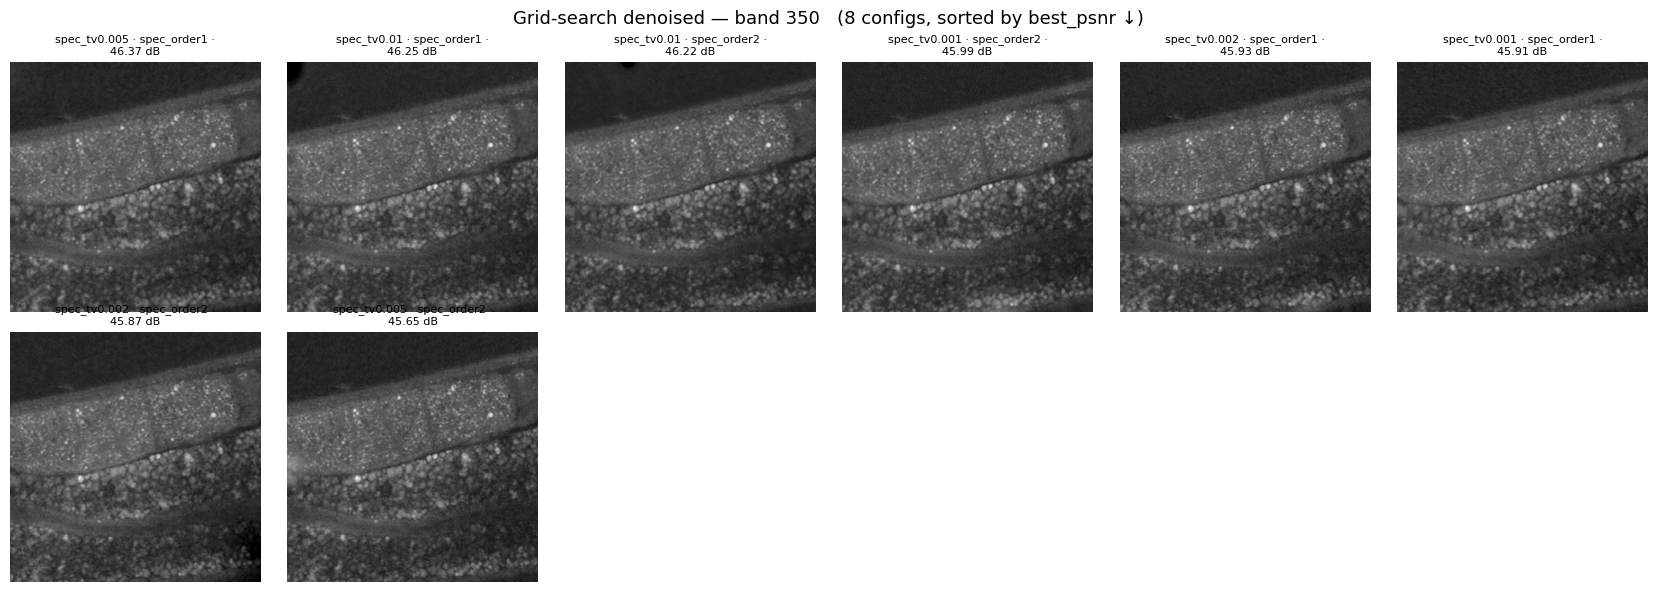

In [201]:
import csv as _csv
from math import ceil

GRID_DIR = 'results/bcars/dip_gridsearch_spectraltv_fine_10000/'   # ← folder holding summary.csv + per-config subdirs
BAND     = 350                          # band to display (0–694)
SORT_BY  = 'best_psnr'                  # any summary.csv column: best_psnr / thres_sstv / mu / alpha_3 / ...
DESCEND  = True                         # True: high→low, False: low→high
NCOLS    = 6                            # tiles per row

def _num(x):
    try:    return float(x)
    except: return float('nan')

# read + sort the summary, keeping only configs that finished
with open(os.path.join(GRID_DIR, 'summary.csv')) as f:
    rows = [r for r in _csv.DictReader(f) if not np.isnan(_num(r.get('best_psnr')))]
rows.sort(key=lambda r: _num(r[SORT_BY]), reverse=DESCEND)

# shared grayscale range from the clean band → panels are directly comparable
vmin, vmax = clean[:, :, BAND].min(), clean[:, :, BAND].max()

n     = len(rows)
ncols = min(NCOLS, n)
nrows = ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(2.8 * ncols, 3.0 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, r in zip(axes, rows):
    cube = np.float32(sio.loadmat(os.path.join(GRID_DIR, r['config'], 'dip_best.mat'))['denoised_phys'])
    ax.imshow(cube[:, :, BAND], cmap='gray', vmin=vmin, vmax=vmax)
    ax.set_title('spec_tv%s · spec_order%s ·\n%.2f dB' %
                 (r['spec_tv'], r['spec_order'],  _num(r['best_psnr'])), fontsize=8)
    ax.axis('off')
for ax in axes[n:]:
    ax.axis('off')

plt.suptitle('Grid-search denoised — band %d   (%d configs, sorted by %s %s)'
             % (BAND, n, SORT_BY, '↓' if DESCEND else '↑'), fontsize=13)
plt.tight_layout(); plt.show()